In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import netCDF4 as nc
import xarray as xr

import sys
sys.path.append("/home/z5297792/UNSW-MRes/MRes/modules") 
from utils import axis_ratio_from_Q, tangential_velocity


In [2]:
# def doppio(x1, y1, u1, v1, x2, y2, u2, v2, degree=3, tol=1e-8, plot=False):
#     from scipy.optimize import least_squares

#     x1, y1, u1, v1 = map(lambda a: np.asarray(a, float), (x1, y1, u1, v1))
#     x2, y2, u2, v2 = map(lambda a: np.asarray(a, float), (x2, y2, u2, v2))

#     m1 = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(u1) & np.isfinite(v1)
#     m2 = np.isfinite(x2) & np.isfinite(y2) & np.isfinite(u2) & np.isfinite(v2)

#     x1, y1, u1, v1 = x1[m1], y1[m1], u1[m1], v1[m1]
#     x2, y2, u2, v2 = x2[m2], y2[m2], u2[m2], v2[m2]

#     nan2 = np.full((2, 2), np.nan)
#     fail = (np.nan, np.nan, np.nan, nan2, np.nan)

#     if x1.size < degree + 1 or x2.size < degree + 1:
#         return fail

#     # find transect intersection
#     P1 = np.c_[x1, y1]
#     P2 = np.c_[x2, y2]
#     d2 = ((P1[:, None, :] - P2[None, :, :])**2).sum(-1)
#     i, j = np.unravel_index(np.argmin(d2), d2.shape)
#     if d2[i, j] > tol**2:
#         return fail

#     cx, cy = P1[i]

#     # local coordinates with transects intersecting at (0,0)
#     xx = x1 - cx
#     yy = y2 - cy

#     # Relationships
#     # A0 = -C1*y0
#     # B0 = A1*y0
#     # C0 = -A1*x0
#     # D0 = -B1*x0
#     # D1 = -A1
    
#     # independent parameters:
#     # x0, y0, A1, B1, C1, A2, A3, B2, B3, C2, C3, D2, D3
#     def residuals(p):
#         x0, y0, A1, B1, C1, A2, A3, B2, B3, C2, C3, D2, D3 = p

#         dx = xx - x0
#         dy = yy - y0

#         U1 = -C1*y0 + A1*dx + A2*dx**2 + A3*dx**3
#         V1 =  A1*y0 + B1*dx + B2*dx**2 + B3*dx**3
#         U2 = -A1*x0 + C1*dy + C2*dy**2 + C3*dy**3
#         V2 = -B1*x0 - A1*dy + D2*dy**2 + D3*dy**3

#         # optional: weight each block similarly
#         s1 = np.nanstd(u1) or 1.0
#         s2 = np.nanstd(v1) or 1.0
#         s3 = np.nanstd(u2) or 1.0
#         s4 = np.nanstd(v2) or 1.0

#         return np.r_[(U1 - u1)/s1, (V1 - v1)/s2, (U2 - u2)/s3, (V2 - v2)/s4]

#     # initial guess from unconstrained cubics about the intersection
#     pu1 = np.polyfit(xx, u1, 3)
#     pv1 = np.polyfit(xx, v1, 3)
#     pu2 = np.polyfit(yy, u2, 3)
#     pv2 = np.polyfit(yy, v2, 3)

#     p0 = np.array([
#         0.0, 0.0,         # x0, y0
#         pu1[2],           # A1
#         pv1[2],           # B1
#         pu2[2],           # C1
#         pu1[1], pu1[0],   # A2, A3
#         pv1[1], pv1[0],   # B2, B3
#         pu2[1], pu2[0],   # C2, C3
#         pv2[1], pv2[0]    # D2, D3
#     ], float)

#     try:
#         res = least_squares(residuals, p0, method="trf")
#     except Exception:
#         return fail

#     x0, y0, A1, B1, C1, A2, A3, B2, B3, C2, C3, D2, D3 = res.x

#     # derivative matrix at (x0, y0)
#     W = np.array([[A1, C1],
#                   [B1, -A1]], float)

#     detW = np.linalg.det(W)
#     if not np.isfinite(detW) or detW <= 0:
#         return fail

#     # W = Omega J Q
#     Omega = np.sign(B1) * np.sqrt(detW)
#     if not np.isfinite(Omega) or Omega == 0:
#         return fail

#     J = -np.array([[0.0, 1.0],
#                   [-1.0, 0.0]])

#     Q = -(J @ W) / Omega
#     Q = 0.5 * (Q + Q.T)

#     detQ = np.linalg.det(Q)
#     if not np.isfinite(detQ) or detQ <= 0:
#         return fail
#     Q /= np.sqrt(detQ)

#     xc = cx + x0
#     yc = cy + y0

#     # zeta = dv/dx - du/dy = -Omega (q11 + q22)
#     w = Omega * (Q[0, 0] + Q[1, 1])

#     # fitted curves on original sample points
#     dx1 = xx - x0
#     dy2 = yy - y0
#     U1 = -C1*y0 + A1*dx1 + A2*dx1**2 + A3*dx1**3
#     V1 =  A1*y0 + B1*dx1 + B2*dx1**2 + B3*dx1**3
#     U2 = -A1*x0 + C1*dy2 + C2*dy2**2 + C3*dy2**3
#     V2 = -B1*x0 - A1*dy2 + D2*dy2**2 + D3*dy2**3

#     if plot:
#         fig, axs = plt.subplots(2, 2, figsize=(8, 6))

#         xs = np.linspace(xx.min(), xx.max(), 200)
#         ys = np.linspace(yy.min(), yy.max(), 200)
#         dxs = xs - x0
#         dys = ys - y0

#         U1s = -C1*y0 + A1*dxs + A2*dxs**2 + A3*dxs**3
#         V1s =  A1*y0 + B1*dxs + B2*dxs**2 + B3*dxs**3
#         U2s = -A1*x0 + C1*dys + C2*dys**2 + C3*dys**3
#         V2s = -B1*x0 - A1*dys + D2*dys**2 + D3*dys**3

#         axs[0, 0].scatter(xx, u1, s=10)
#         axs[0, 0].plot(xs, U1s)
#         axs[0, 0].set_title("U1(x)")

#         axs[0, 1].scatter(xx, v1, s=10)
#         axs[0, 1].plot(xs, V1s)
#         axs[0, 1].set_title("V1(x)")

#         axs[1, 0].scatter(yy, u2, s=10)
#         axs[1, 0].plot(ys, U2s)
#         axs[1, 0].set_title("U2(y)")

#         axs[1, 1].scatter(yy, v2, s=10)
#         axs[1, 1].plot(ys, V2s)
#         axs[1, 1].set_title("V2(y)")

#         plt.tight_layout()
#         plt.show()

#     return xc, yc, w, Q, Omega


In [3]:
def doppio(
    x1, y1, u1, v1, x2, y2, u2, v2,
    degree=3, tol=1e-8, plot=False,
    use_A0=True, use_B0=True, use_C0=True, use_D0=True, use_D1=True
):
    from scipy.optimize import least_squares

    x1, y1, u1, v1 = map(lambda a: np.asarray(a, float), (x1, y1, u1, v1))
    x2, y2, u2, v2 = map(lambda a: np.asarray(a, float), (x2, y2, u2, v2))

    m1 = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(u1) & np.isfinite(v1)
    m2 = np.isfinite(x2) & np.isfinite(y2) & np.isfinite(u2) & np.isfinite(v2)
    x1, y1, u1, v1 = x1[m1], y1[m1], u1[m1], v1[m1]
    x2, y2, u2, v2 = x2[m2], y2[m2], u2[m2], v2[m2]

    nan2 = np.full((2, 2), np.nan)
    fail = (np.nan, np.nan, np.nan, nan2, np.nan)

    if x1.size < degree + 1 or x2.size < degree + 1:
        return fail

    # intersection of transects
    P1 = np.c_[x1, y1]
    P2 = np.c_[x2, y2]
    d2 = ((P1[:, None, :] - P2[None, :, :])**2).sum(-1)
    i, j = np.unravel_index(np.argmin(d2), d2.shape)
    if d2[i, j] > tol**2:
        return fail

    cx, cy = P1[i]
    xx = x1 - cx
    yy = y2 - cy

    pu1 = np.polyfit(xx, u1, 3)  # [A3,A2,A1,A0] about xx=0
    pv1 = np.polyfit(xx, v1, 3)  # [B3,B2,B1,B0]
    pu2 = np.polyfit(yy, u2, 3)  # [C3,C2,C1,C0]
    pv2 = np.polyfit(yy, v2, 3)  # [D3,D2,D1,D0]

    # dynamic parameter vector
    names = ["x0", "y0", "A1", "B1", "C1", "A2", "A3", "B2", "B3", "C2", "C3", "D2", "D3"]
    p0 = [0.0, 0.0, pu1[2], pv1[2], pu2[2], pu1[1], pu1[0], pv1[1], pv1[0], pu2[1], pu2[0], pv2[1], pv2[0]]

    if not use_A0:
        names += ["A0"]
        p0 += [pu1[3]]
    if not use_B0:
        names += ["B0"]
        p0 += [pv1[3]]
    if not use_C0:
        names += ["C0"]
        p0 += [pu2[3]]
    if not use_D0:
        names += ["D0"]
        p0 += [pv2[3]]
    if not use_D1:
        names += ["D1"]
        p0 += [pv2[2]]

    name_to_idx = {n: k for k, n in enumerate(names)}

    def get(p, name):
        return p[name_to_idx[name]]

    def residuals(p):
        x0 = get(p, "x0")
        y0 = get(p, "y0")
        A1 = get(p, "A1")
        B1 = get(p, "B1")
        C1 = get(p, "C1")
        A2 = get(p, "A2")
        A3 = get(p, "A3")
        B2 = get(p, "B2")
        B3 = get(p, "B3")
        C2 = get(p, "C2")
        C3 = get(p, "C3")
        D2 = get(p, "D2")
        D3 = get(p, "D3")

        A0 = -C1*y0 if use_A0 else get(p, "A0")
        B0 =  A1*y0 if use_B0 else get(p, "B0")
        C0 = -A1*x0 if use_C0 else get(p, "C0")
        D0 = -B1*x0 if use_D0 else get(p, "D0")
        D1 = -A1    if use_D1 else get(p, "D1")

        dx = xx - x0
        dy = yy - y0

        U1 = A0 + A1*dx + A2*dx**2 + A3*dx**3
        V1 = B0 + B1*dx + B2*dx**2 + B3*dx**3
        U2 = C0 + C1*dy + C2*dy**2 + C3*dy**3
        V2 = D0 + D1*dy + D2*dy**2 + D3*dy**3

        s1 = np.nanstd(u1) or 1.0
        s2 = np.nanstd(v1) or 1.0
        s3 = np.nanstd(u2) or 1.0
        s4 = np.nanstd(v2) or 1.0

        return np.r_[(U1 - u1)/s1, (V1 - v1)/s2, (U2 - u2)/s3, (V2 - v2)/s4]

    try:
        res = least_squares(residuals, np.array(p0, float), method="trf")
    except Exception:
        return fail

    p = res.x
    x0 = get(p, "x0")
    y0 = get(p, "y0")
    A1 = get(p, "A1")
    B1 = get(p, "B1")
    C1 = get(p, "C1")
    A2 = get(p, "A2")
    A3 = get(p, "A3")
    B2 = get(p, "B2")
    B3 = get(p, "B3")
    C2 = get(p, "C2")
    C3 = get(p, "C3")
    D2 = get(p, "D2")
    D3 = get(p, "D3")

    A0 = -C1*y0 if use_A0 else get(p, "A0")
    B0 =  A1*y0 if use_B0 else get(p, "B0")
    C0 = -A1*x0 if use_C0 else get(p, "C0")
    D0 = -B1*x0 if use_D0 else get(p, "D0")
    D1 = -A1    if use_D1 else get(p, "D1")

    # derivative matrix at fitted closest-approach points
    W = np.array([[A1, B1],
                  [C1, D1]], float)

    detW = np.linalg.det(W)
    if not np.isfinite(detW) or detW <= 0:
        return fail

    Omega = np.sign(B1) * np.sqrt(detW)
    if not np.isfinite(Omega) or Omega == 0:
        return fail

    J = np.array([[0.0, 1.0],
                  [-1.0, 0.0]])

    # keep your current sign convention
    Q = -(J @ W) / Omega
    # Q = 0.5 * (Q + Q.T)

    detQ = np.linalg.det(Q)
    if not np.isfinite(detQ) or detQ <= 0:
        return fail
    Q /= np.sqrt(detQ)

    x0 = -C0/A1 # -D0/B1
    print(np.abs(-C0/A1 + D0/B1))
    y0 = -A0/C1 #  B0/A1
    print(np.abs(-A0/C1 - B0/A1))

    xc = cx + x0
    yc = cy + y0
    w = Omega * (Q[0, 0] + Q[1, 1])

    dx1 = xx - x0
    dy2 = yy - y0
    U1 = A0 + A1*dx1 + A2*dx1**2 + A3*dx1**3
    V1 = B0 + B1*dx1 + B2*dx1**2 + B3*dx1**3
    U2 = C0 + C1*dy2 + C2*dy2**2 + C3*dy2**3
    V2 = D0 + D1*dy2 + D2*dy2**2 + D3*dy2**3

    if plot:
        fig, axs = plt.subplots(2, 2, figsize=(8, 6))

        xs = np.linspace(xx.min(), xx.max(), 200)
        ys = np.linspace(yy.min(), yy.max(), 200)
        dxs = xs - x0
        dys = ys - y0

        U1s = A0 + A1*dxs + A2*dxs**2 + A3*dxs**3
        V1s = B0 + B1*dxs + B2*dxs**2 + B3*dxs**3
        U2s = C0 + C1*dys + C2*dys**2 + C3*dys**3
        V2s = D0 + D1*dys + D2*dys**2 + D3*dys**3

        axs[0, 0].scatter(xx, u1, s=10)
        axs[0, 0].plot(xs, U1s)
        axs[0, 0].set_title("U1(x)")

        axs[0, 1].scatter(xx, v1, s=10)
        axs[0, 1].plot(xs, V1s)
        axs[0, 1].set_title("V1(x)")

        axs[1, 0].scatter(yy, u2, s=10)
        axs[1, 0].plot(ys, U2s)
        axs[1, 0].set_title("U2(y)")

        axs[1, 1].scatter(yy, v2, s=10)
        axs[1, 1].plot(ys, V2s)
        axs[1, 1].set_title("V2(y)")

        plt.tight_layout()
        plt.show()

    return xc, yc, w, Q, Omega#, U1, V1, U2, V2
    

In [4]:
def param_finder(x1, y1, u1, v1, x2, y2, u2, v2, tol=1e-8):
    from scipy.optimize import least_squares

    x1, y1, u1, v1 = map(lambda a: np.asarray(a, float), (x1, y1, u1, v1))
    x2, y2, u2, v2 = map(lambda a: np.asarray(a, float), (x2, y2, u2, v2))

    m1 = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(u1) & np.isfinite(v1)
    m2 = np.isfinite(x2) & np.isfinite(y2) & np.isfinite(u2) & np.isfinite(v2)
    x1, y1, u1, v1 = x1[m1], y1[m1], u1[m1], v1[m1]
    x2, y2, u2, v2 = x2[m2], y2[m2], u2[m2], v2[m2]

    fail = (np.full(4, np.nan), np.full(4, np.nan), np.full(4, np.nan), np.full(4, np.nan), np.nan, np.nan)

    if x1.size < 4 or x2.size < 4:
        return fail

    P1 = np.c_[x1, y1]
    P2 = np.c_[x2, y2]
    d2 = ((P1[:, None, :] - P2[None, :, :])**2).sum(-1)
    i, j = np.unravel_index(np.argmin(d2), d2.shape)
    if d2[i, j] > tol**2:
        return fail

    cx, cy = P1[i]
    xx = x1 - cx
    yy = y2 - cy

    n1, n2 = xx.size, yy.size

    def solve_coeffs(x0, y0):
        dx = xx - x0
        dy = yy - y0

        X1 = np.column_stack([np.ones(n1), dx, dx**2, dx**3])
        Y2 = np.column_stack([np.ones(n2), dy, dy**2, dy**3])

        M = np.zeros((2 * n1 + 2 * n2, 15))
        rhs = np.concatenate([u1, v1, u2, v2])

        M[:n1, 0:4] = X1
        M[n1:2*n1, 4:8] = X1
        M[2*n1:2*n1+n2, 8:12] = Y2

        M[2*n1+n2:, 12] = 1.0
        M[2*n1+n2:, 1] = -dy
        M[2*n1+n2:, 13] = dy**2
        M[2*n1+n2:, 14] = dy**3

        beta, *_ = np.linalg.lstsq(M, rhs, rcond=None)
        return beta, M @ beta - rhs

    def residuals(z):
        _, r = solve_coeffs(z[0], z[1])
        return r

    z0 = np.array([0.0, 0.0])
    res = least_squares(residuals, z0)

    if not res.success:
        return fail

    x0, y0 = res.x
    beta, _ = solve_coeffs(x0, y0)

    A = beta[0:4]
    B = beta[4:8]
    C = beta[8:12]
    D = np.array([beta[12], -beta[1], beta[13], beta[14]])

    df = pd.DataFrame(
        np.vstack([A, B, C, D]),
        index=["A","B","C","D"],
        columns=["0","1","2","3"]
    )
    
    return df, x0, y0


In [5]:
def out_core_param_fit(
    rho2, Qr, vt,
    Omega0=None, Rc0=None,
    plot=False, ax=None,
    maxfev=10000, Rc_max=1e5,
    r2_flag=False,
    rho_plot_max=None, n_curve=400,
    km_flag=False,
    ci_flag=False,
    pred_flag=False
):

    from scipy.optimize import curve_fit

    rho2 = np.asarray(rho2, float)
    Qr   = np.asarray(Qr, float)
    vt   = np.asarray(vt, float)

    m = np.isfinite(rho2) & np.isfinite(Qr) & np.isfinite(vt) & (rho2 >= 0) & (Qr != 0)
    if not np.any(m):
        return (np.nan, np.nan, np.nan, np.nan) if r2_flag else (np.nan, np.nan, np.nan)

    rho2 = rho2[m]
    Qr   = Qr[m]
    vt   = vt[m]

    rho = np.sqrt(rho2)
    vt = vt * (rho / Qr)

    def vt_model(r2, Omega, Rc):
        return Omega * np.sqrt(r2) * np.exp(-r2 / (Rc**2))

    i = np.nanargmax(np.abs(vt))
    rho_max = rho[i]

    if Rc0 is None:
        Rc0 = max(rho_max * np.sqrt(2), 1e-6)

    if Omega0 is None:
        denom = rho * np.exp(-rho2 / (Rc0**2))
        ok = np.abs(denom) > 0
        Omega0 = np.nanmedian(vt[ok] / denom[ok]) if np.any(ok) else 0

    if not np.isfinite(Omega0):
        Omega0 = 0

    pcov = None
    try:
        popt, pcov = curve_fit(
            vt_model, rho2, vt,
            p0=[Omega0, Rc0],
            bounds=([-np.inf, 1e-8], [np.inf, np.inf]),
            maxfev=maxfev
        )
        Omega_opt, Rc_opt = popt
    except:
        Omega_opt, Rc_opt = Omega0, Rc0

    if (not np.isfinite(Rc_opt)) or (Rc_opt > Rc_max):
        Omega_opt, Rc_opt = Omega0, Rc0
        pcov = None

    psi0_opt = -0.5 * Omega_opt * Rc_opt**2

    vt_fit = vt_model(rho2, Omega_opt, Rc_opt)

    ss_res = np.sum((vt - vt_fit)**2)
    ss_tot = np.sum((vt - vt.mean())**2)
    R2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    dof = max(len(vt) - 2, 1)
    sigma2 = ss_res / dof

    if plot:

        if ax is None:
            fig, ax = plt.subplots()

        if rho_plot_max is None:
            rho_plot_max = np.nanmax(rho)

        r_grid = np.linspace(0, rho_plot_max, n_curve)
        r2_grid = r_grid**2

        vt_grid = vt_model(r2_grid, Omega_opt, Rc_opt)

        if km_flag:
            core_mask = rho <= 30
        else:
            core_mask = rho <= 30_000

        ax.scatter(rho[core_mask], np.abs(vt[core_mask]), s=10, color='m', label='Core observed')
        ax.scatter(rho[~core_mask], np.abs(vt[~core_mask]), s=10, color='g', label='Outer-core observed')

        ax.plot(r_grid, np.abs(vt_grid), lw=2, color='b', label='')
        ax.axvline(Rc_opt / np.sqrt(2), ls='--', color='r', label='', lw=2)

        if pcov is not None:

            exp_term = np.exp(-r2_grid / (Rc_opt**2))

            dOmega = np.sqrt(r2_grid) * exp_term
            dRc = 2 * Omega_opt * (r2_grid**1.5) * exp_term / (Rc_opt**3)

            J = np.vstack([dOmega, dRc]).T
            var_model = np.einsum("ij,jk,ik->i", J, pcov, J)

            if ci_flag:
                se_model = np.sqrt(np.maximum(var_model, 0))
                lo = vt_grid - 1.96 * se_model
                hi = vt_grid + 1.96 * se_model

                ax.fill_between(
                    r_grid, np.abs(lo), np.abs(hi),
                    color='orange', alpha=.2, label='95% CI'
                )

            if pred_flag:
                se_pred = np.sqrt(np.maximum(var_model + sigma2, 0))
                lo = vt_grid - 1.96 * se_pred
                hi = vt_grid + 1.96 * se_pred

                ax.fill_between(
                    r_grid, np.abs(lo), np.abs(hi),
                    color='b', alpha=.15, label=''
                )

        ax.set_xlabel(r'$\rho$')
        ax.set_ylabel(r'$|v_t^\star|$')

        ax.set_title(
            f"Omega={Omega_opt:.3g}, Rc={Rc_opt:.3g}, psi0={psi0_opt:.3g}, R²={R2:.2f}"
        )

        ax.legend()

    return (Rc_opt, psi0_opt, Omega_opt, R2) if r2_flag else (Rc_opt, psi0_opt, Omega_opt)
    

In [6]:
def doppio_pipeliner(nxc, nyc, ut, vt, X_new, Y_new, r=30000.0):
    nan = (np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan)

    x = np.asarray(X_new[:, 0], float)
    y = np.asarray(Y_new[0, :], float)

    dx = np.nanmedian(np.abs(np.diff(x)))
    dy = np.nanmedian(np.abs(np.diff(y)))
    cell = np.nanmax([dx, dy])
    if not np.isfinite(cell) or cell == 0:
        return nan

    margin = int(np.ceil(r / cell))

    ic = int(np.clip(np.searchsorted(x, nxc), 1, x.size-1))
    ic -= (nxc - x[ic-1] < x[ic] - nxc)
    jc = int(np.clip(np.searchsorted(y, nyc), 1, y.size-1))
    jc -= (nyc - y[jc-1] < y[jc] - nyc)

    if ic < margin or ic >= x.size - margin or jc < margin or jc >= y.size - margin:
        return nan

    # x-transect (y = y[jc])
    i0 = np.searchsorted(x, nxc - r, side="left")
    i1 = np.searchsorted(x, nxc + r, side="right")
    x1 = x[i0:i1]
    y1 = np.full(x1.size, y[jc])
    u1 = ut[i0:i1, jc]
    v1 = vt[i0:i1, jc]

    # y-transect (x = x[ic])
    j0 = np.searchsorted(y, nyc - r, side="left")
    j1 = np.searchsorted(y, nyc + r, side="right")
    y2 = y[j0:j1]
    x2 = np.full(y2.size, x[ic])
    u2 = ut[ic, j0:j1]
    v2 = vt[ic, j0:j1]

    return x1, y1, u1, v1, x2, y2, u2, v2
    

### Numerical Data

In [7]:
ssh_path = '/srv/scratch/z5297792/ESP_Paper_Data/sat_data_copernicus_CCE_2023_1D.nc'
ds_nc = nc.Dataset(ssh_path)

lon, lat = ds_nc['longitude'][:], ds_nc['latitude'][:]
u = np.squeeze(ds_nc['uo'][:]); v = np.squeeze(ds_nc['vo'][:])
# u, v = np.transpose(u, (2,1,0)), np.transpose(v, (2,1,0))  # (time, lat, lon)
t = pd.Timestamp("1950-01-01") + pd.to_timedelta(ds_nc['time'][:], "h")
u, v = np.where(np.abs(u) < 100, u, np.nan), np.where(np.abs(v) < 100, v, np.nan)
lon2d, lat2d = np.meshgrid(lon, lat, indexing="xy")
theta_mean, phi_mean = 154.3, -37.9
x = (lon2d-theta_mean)*111000*np.cos(np.deg2rad(phi_mean))
y = (lat2d-phi_mean)*111000
ds_cop = xr.Dataset(
    {"u": (("time","lat","lon"), u),
     "v": (("time","lat","lon"), v)},
    coords={"time": t, "lat": lat, "lon": lon,
            "x": (("lat","lon"), x),
            "y": (("lat","lon"), y)}
)
ds_cop["land_mask"] = np.isnan(ds_cop.u.isel(time=0)) & np.isnan(ds_cop.v.isel(time=0))
# # Time slice
ds_cop = ds_cop.sel(time=ds_cop.time <= np.datetime64('2024-01-27T00:00:00.000000000'))

print(ds_cop.time.min(), ds_cop.time.max())
print(ds_cop.lat.min(), ds_cop.lat.max())
print(ds_cop.lon.min(), ds_cop.lon.max())

ds_cop


<xarray.DataArray 'time' ()> Size: 8B
array('2023-10-19T00:00:00.000000000', dtype='datetime64[ns]') <xarray.DataArray 'time' ()> Size: 8B
array('2024-01-27T00:00:00.000000000', dtype='datetime64[ns]')
<xarray.DataArray 'lat' ()> Size: 4B
array(-42., dtype=float32) <xarray.DataArray 'lat' ()> Size: 4B
array(-34., dtype=float32)
<xarray.DataArray 'lon' ()> Size: 4B
array(149., dtype=float32) <xarray.DataArray 'lon' ()> Size: 4B
array(158., dtype=float32)


<xarray.Dataset> Size: 9MB
Dimensions:    (time: 101, lat: 97, lon: 109)
Coordinates:
  * time       (time) datetime64[ns] 808B 2023-10-19 ... 2024-01-27
  * lat        (lat) float32 388B -42.0 -41.92 -41.83 ... -34.17 -34.08 -34.0
  * lon        (lon) float32 436B 149.0 149.1 149.2 149.2 ... 157.8 157.9 158.0
    x          (lat, lon) float64 85kB -4.642e+05 -4.569e+05 ... 3.241e+05
    y          (lat, lon) float64 85kB -4.551e+05 -4.551e+05 ... 4.329e+05
Data variables:
    u          (time, lat, lon) float32 4MB -0.284 -0.3366 ... 0.3254 0.346
    v          (time, lat, lon) float32 4MB -0.2342 -0.1941 ... -0.1586 -0.1242
    land_mask  (lat, lon) bool 11kB False False False ... False False False

14374.267487515768
114602.48492193087


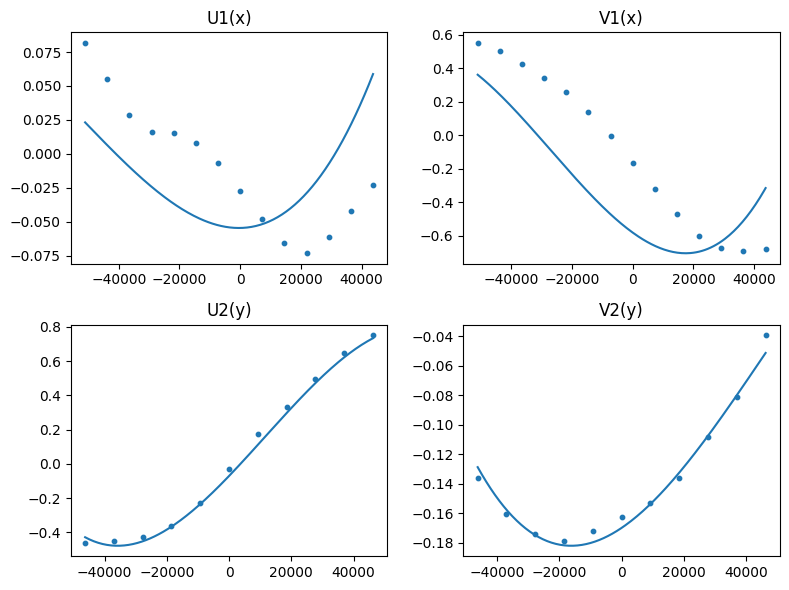

(          0         1             2             3
A -0.035668 -0.000002  2.581971e-11  3.045528e-16
B -0.181871 -0.000021  4.704075e-11  3.503382e-15
C -0.035171  0.000019  8.788196e-11 -2.986865e-15
D -0.167120  0.000002  3.583854e-11 -2.891583e-16, np.float64(1.4622484253524975e-08), np.float64(5.1855317462445245e-09))
28551.9566883114
109868.6327485678


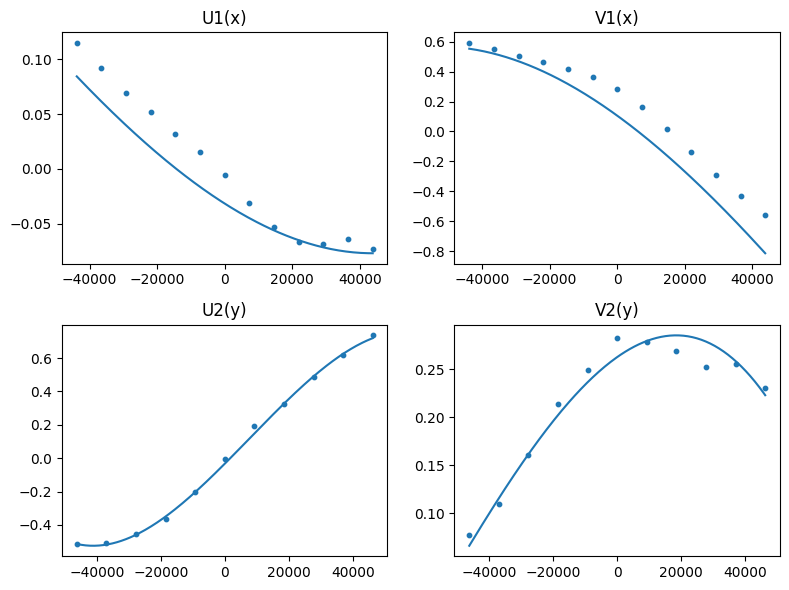

(          0         1             2             3
A -0.011264 -0.000002  1.666544e-11  4.364426e-17
B  0.249987 -0.000014 -1.344074e-10  4.037764e-16
C -0.021840  0.000019  5.878977e-11 -2.756296e-15
D  0.264251  0.000002 -5.588021e-11 -2.907993e-16, np.float64(5.326397096694033e-13), np.float64(-4.775232168109365e-12))
54469.091041829925
259720.38065865028


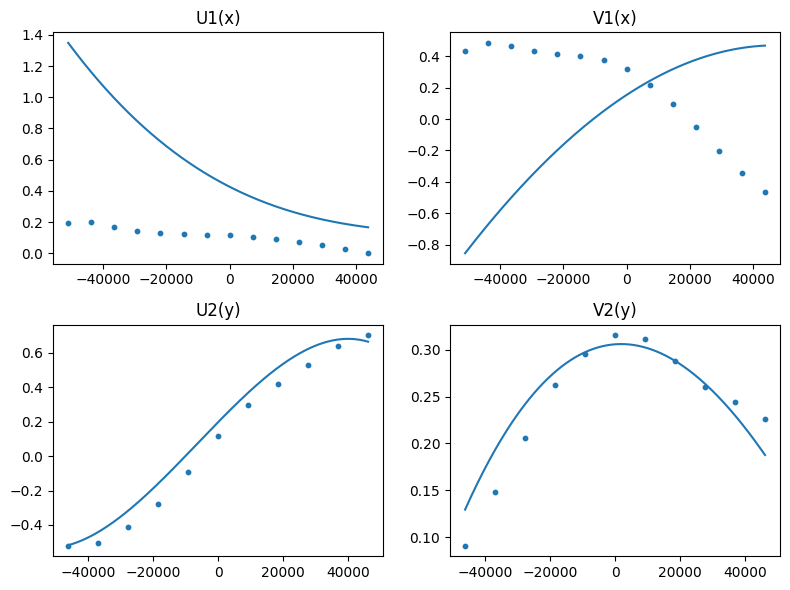

(          0         1             2             3
A  0.111580 -0.000001 -1.235344e-11 -5.719293e-16
B  0.280600 -0.000011 -1.559864e-10 -9.347085e-17
C  0.087442  0.000020 -6.498372e-12 -3.035081e-15
D  0.302106  0.000001 -7.182529e-11  1.966146e-16, np.float64(-5.867306221749389e-10), np.float64(-2.6455502633235246e-10))
803643.02248297
688821.0413429477


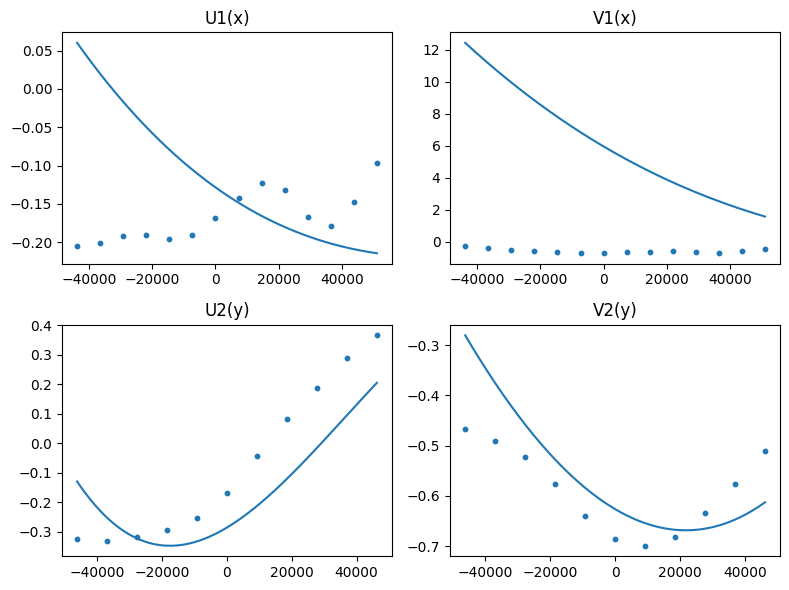

(          0         1             2             3
A -0.170512  0.000002  2.388480e-12 -4.526749e-16
B -0.674937 -0.000001  1.406618e-10 -1.209485e-15
C -0.144170  0.000010  8.300741e-11 -1.399534e-15
D -0.665788 -0.000002  8.893429e-11  4.939626e-16, np.float64(1.6456618601073016e-08), np.float64(-1.4784079783951573e-09))


,xc,yc,w,Q,Omega,time,alpha
0,-19595.592233,-5.993137,-0.000040,"[[0.9730942850035292, 0.07868979552826301], [0...",-0.000020,2023-10-19 00:00:00,1.087933
1,-28515.695486,-1266.059563,-0.000033,"[[1.1900236006818017, 0.1410549942114665], [0....",-0.000016,2023-10-19 23:56:15,1.241743
2,56390.766286,-7522.260246,-0.000030,"[[1.358036051135097, 0.07305714337277433], [0....",-0.000014,2023-10-21 00:00:00,1.366558


In [8]:
xc_pre, yc_pre = 0.0, 0.0
rows = []
xyuv_rows = []

X = ds_cop.x.values
Y = ds_cop.y.values

for t, time in enumerate(ds_cop.time.values):
    ut = ds_cop.u.sel(time=time).values
    vt = ds_cop.v.sel(time=time).values

    x1,y1,u1,v1,x2,y2,u2,v2 = doppio_pipeliner(xc_pre, yc_pre, ut.T, vt.T, X.T, Y.T, r=50_000)
    xc, yc, w, Q, Omega = doppio(x1,y1,u1,v1, x2,y2,u2,v2, plot=True,# if t==0 else False,
                                use_A0=False, use_B0=False, use_C0=False, use_D0=False, use_D1=True)

    print(param_finder(x1,y1,u1,v1, x2,y2,u2,v2))

    ok = (np.isfinite(xc) and np.isfinite(yc) and
          (np.hypot(xc-xc_pre, yc-yc_pre) < 100_000) and (w < 0))

    if not ok:
        break

    rows.append(dict(xc=xc, yc=yc, w=w, Q=Q, Omega=Omega, time=time))
    xc_pre, yc_pre = xc, yc

    xi = np.concatenate([x1, x2])
    yi = np.concatenate([y1, y2])
    ui = np.concatenate([u1, u2])
    vi = np.concatenate([v1, v2])

    xyuv_rows.append(pd.DataFrame({
        "time": time,
        "core": "inner",
        "xi": xi, "yi": yi, "ui": ui, "vi": vi
    }))

df_res = pd.DataFrame(rows, columns=["xc","yc","w","Q","Omega","time"])
df_res["alpha"] = [axis_ratio_from_Q(Q) for Q in df_res["Q"].to_list()]

df_xyuv = pd.concat(xyuv_rows, ignore_index=True) if xyuv_rows else pd.DataFrame(
    columns=["time","core","xi","yi","ui","vi"]
)

df_res


(np.float64(-32761.018574782116),
 np.float64(60636.08937420909),
 np.float64(-7898.073600995781),
 np.float64(369.82021891725077))

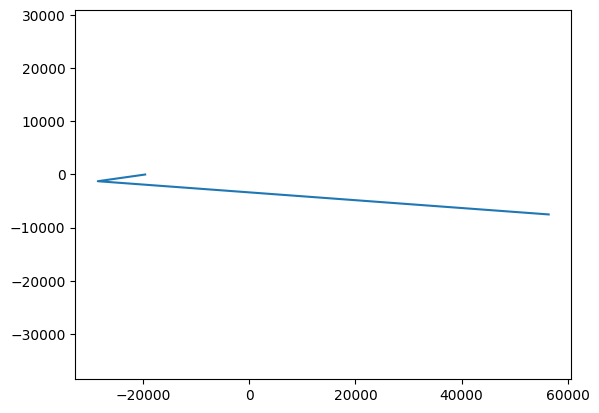

In [9]:
plt.plot(df_res.xc, df_res.yc)
plt.axis('equal')


In [10]:
rho_outer = 100_000.0

xi0 = ds_cop.x.values.ravel()
yi0 = ds_cop.y.values.ravel()

Rc_opts, psi0_opts, Omega_opts = [], [], []
xyuv_rows = []

for k, data in df_res.iterrows():
    time = data.time

    ui0 = ds_cop.u.sel(time=time).values.ravel()
    vi0 = ds_cop.v.sel(time=time).values.ravel()

    xc, yc = float(data.xc), float(data.yc)
    Q = np.asarray(data.Q)
    Omega = float(data.Omega)
    q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]

    dx = xi0 - xc
    dy = yi0 - yc
    rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy

    outer = rho2 <= rho_outer**2
    xi_o, yi_o = xi0[outer], yi0[outer]
    ui_o, vi_o = ui0[outer], vi0[outer]
    dx_o, dy_o, rho2_o = dx[outer], dy[outer], rho2[outer]

    xyuv_rows.append(pd.DataFrame({
        "time": time, "core": "outer",
        "xi": xi_o, "yi": yi_o, "ui": ui_o, "vi": vi_o
    }))

    vt_o = tangential_velocity(xi_o, yi_o, ui_o, vi_o, xc, yc, Q)
    Qr_o = np.sqrt((q11*dx_o + q12*dy_o)**2 + (q12*dx_o + q22*dy_o)**2)

    sign_mask = (vt_o <= 0) if (Omega < 0) else (vt_o >= 0)
    rho2_f, Qr_f, vt_f = rho2_o[sign_mask], Qr_o[sign_mask], vt_o[sign_mask]

    Rc_opt, psi0_opt, Omega_opt = out_core_param_fit(rho2_f, Qr_f, vt_f, Omega0=Omega, plot=(k == 10), pred_flag=True)
    Rc_opts.append(Rc_opt); psi0_opts.append(psi0_opt); Omega_opts.append(Omega_opt)

df_xyuv_o = pd.concat(xyuv_rows, ignore_index=True) if xyuv_rows else pd.DataFrame(
    columns=["time","core","xi","yi","ui","vi"]
)

df_xyuv = pd.concat([df_xyuv, df_xyuv_o], ignore_index=True)
df_xyuv = (
    df_xyuv
    .sort_values(by="core", key=lambda s: s.eq("outer"))  # keep inner first
    .drop_duplicates(subset=["time", "xi", "yi", "ui", "vi"], keep="first")
    .reset_index(drop=True)
)

df_res["Rc"] = Rc_opts
df_res["psi0"] = psi0_opts
df_res["Omega"] = Omega_opts
df_res["w"] = [Omega*(Q[0,0] + Q[1,1]) for (A,Q) in zip(df_res.Omega, df_res.Q)]
df_res


,xc,yc,w,Q,Omega,time,alpha,Rc,psi0
0,-19595.592233,-5.993137,-0.000029,"[[0.9730942850035292, 0.07868979552826301], [0...",-0.000018,2023-10-19 00:00:00,1.087933,83500.782111,61418.812842
1,-28515.695486,-1266.059563,-0.000030,"[[1.1900236006818017, 0.1410549942114665], [0....",-0.000016,2023-10-19 23:56:15,1.241743,85691.097353,57149.292996
2,56390.766286,-7522.260246,-0.000030,"[[1.358036051135097, 0.07305714337277433], [0....",-0.000016,2023-10-21 00:00:00,1.366558,63544.380854,32967.723026


In [11]:
# # Find r2
# def model_uv_at_xy(xi, yi, xc, yc, Q, A, Rc):
#     dx = xi - xc
#     dy = yi - yc
#     q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]
#     rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy
#     fac = A * np.exp(-rho2 / (Rc*Rc))
#     uhat = -fac * (2*q12*dx + 2*q22*dy)
#     vhat =  fac * (2*q11*dx + 2*q12*dy)
#     return uhat, vhat
    
# def vector_r2(u, v, uhat, vhat):
#     m = np.isfinite(u) & np.isfinite(v) & np.isfinite(uhat) & np.isfinite(vhat)
#     if not np.any(m):
#         return np.nan
#     u, v, uhat, vhat = u[m], v[m], uhat[m], vhat[m]
#     err2 = (uhat - u)**2 + (vhat - v)**2
#     u0, v0 = np.mean(u), np.mean(v)
#     tot2 = (u - u0)**2 + (v - v0)**2
#     return 1 - np.sum(err2)/np.sum(tot2) if np.sum(tot2) > 0 else np.nan

# r2_vals = []
# for _, row in df_res.iterrows():
#     df = df_xyuv[df_xyuv.time == row.time]
#     xi = df.xi.to_numpy(float)
#     yi = df.yi.to_numpy(float)
#     u  = df.ui.to_numpy(float)
#     v  = df.vi.to_numpy(float)
#     uhat, vhat = model_uv_at_xy(xi, yi, row.xc, row.yc, np.asarray(row.Q), row.A, row.Rc)
#     r2_vals.append(vector_r2(u, v, uhat, vhat))

# df_res["r2"] = r2_vals


# Find R2
def model_uv_at_xy(xi, yi, xc, yc, Q, Omega, Rc):
    dx = xi - xc
    dy = yi - yc

    q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]

    rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy
    fac = Omega * np.exp(-rho2 / (Rc*Rc))

    uhat = -fac * (q12*dx + q22*dy)
    vhat =  fac * (q11*dx + q12*dy)

    return uhat, vhat
    
def vector_R2(u, v, uhat, vhat):
    m = np.isfinite(u) & np.isfinite(v) & np.isfinite(uhat) & np.isfinite(vhat)
    if not np.any(m):
        return np.nan
    u, v, uhat, vhat = u[m], v[m], uhat[m], vhat[m]
    err2 = (uhat - u)**2 + (vhat - v)**2
    u0, v0 = np.mean(u), np.mean(v)
    tot2 = (u - u0)**2 + (v - v0)**2
    return 1 - np.sum(err2)/np.sum(tot2) if np.sum(tot2) > 0 else np.nan

R2_vals = []
for _, row in df_res.iterrows():
    df = df_xyuv[df_xyuv.time == row.time]
    xi = df.xi.to_numpy(float)
    yi = df.yi.to_numpy(float)
    u  = df.ui.to_numpy(float)
    v  = df.vi.to_numpy(float)
    uhat, vhat = model_uv_at_xy(xi, yi, row.xc, row.yc, np.asarray(row.Q), row.Omega, row.Rc)
    R2_vals.append(vector_R2(u, v, uhat, vhat))
df_res['R2'] = R2_vals
df_res


,xc,yc,w,Q,Omega,time,alpha,Rc,psi0,R2
0,-19595.592233,-5.993137,-0.000029,"[[0.9730942850035292, 0.07868979552826301], [0...",-0.000018,2023-10-19 00:00:00,1.087933,83500.782111,61418.812842,0.875754
1,-28515.695486,-1266.059563,-0.000030,"[[1.1900236006818017, 0.1410549942114665], [0....",-0.000016,2023-10-19 23:56:15,1.241743,85691.097353,57149.292996,0.769181
2,56390.766286,-7522.260246,-0.000030,"[[1.358036051135097, 0.07305714337277433], [0....",-0.000016,2023-10-21 00:00:00,1.366558,63544.380854,32967.723026,-0.605820


In [12]:
X = ds_cop.x.values
Y = ds_cop.y.values
nt = len(df_res)

U = np.empty((nt, X.shape[0], X.shape[1]))
V = np.empty((nt, X.shape[0], X.shape[1]))

for k in range(nt):
    data = df_res.iloc[k]

    dx = X - data.xc
    dy = Y - data.yc

    q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]

    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
    fac = data.A * np.exp(-rho2 / data.Rc**2)

    U[k] = -fac * (2*q12*dx + 2*q22*dy)
    V[k] =  fac * (2*q11*dx + 2*q12*dy)

mask = ds_cop.land_mask.values[None, :, :]   # (1, lat, lon)
U = np.where(mask, np.nan, U)
V = np.where(mask, np.nan, V)

ds_model = xr.Dataset(
    data_vars=dict(
        u=(("time","lat","lon"), U),
        v=(("time","lat","lon"), V),
    ),
    coords=dict(
        time=df_res.time.values,
        lat=ds_cop.lat.values,
        lon=ds_cop.lon.values,
        x=(("lat","lon"), X),
        y=(("lat","lon"), Y),
    ),
)

AttributeError: 'Series' object has no attribute 'A'

In [ ]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.dates as mdates

def plot__model(df_res, ds_cop, ds_model, df_xyuv, time=None, spac=1, scale=20,
                xlim=(-410, 200), ylim=(-160, 260), out_thresh=False, plot_data=False):

    if time is None:
        time = ds_model.time.values[0]

    sat = ds_cop.sel(time=time, method="nearest")
    mod = ds_model.sel(time=time, method="nearest")
    data = df_res[df_res.time == time].iloc[0]

    X = sat.x.values / 1e3
    Y = sat.y.values / 1e3

    us, vs = sat.u.values, sat.v.values
    um, vm = mod.u.values, mod.v.values

    sp_s = np.hypot(us, vs)
    sp_m = np.hypot(um, vm)

    dx, dy = sat.x.values - data.xc, sat.y.values - data.yc
    q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]
    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2

    roi = (X >= xlim[0]) & (X <= xlim[1]) & (Y >= ylim[0]) & (Y <= ylim[1])
    sp_s_roi = np.where(roi, sp_s, np.nan)
    sp_m_roi = np.where(roi, sp_m, np.nan)
    roi_quiv = roi & (rho2 >= 100_000**2)

    vals = np.concatenate([sp_s_roi[roi], sp_m_roi[roi]])
    vmax = np.nanmax(vals)
    levels = np.arange(0, vmax + .05, .05)

    X_rho, Y_rho = np.meshgrid(np.linspace(xlim[0]*1e3, xlim[1]*1e3, 100),
                               np.linspace(ylim[0]*1e3, ylim[1]*1e3, 100))
    dx = X_rho - data.xc
    dy = Y_rho - data.yc
    rho2 = data.Q[0,0]*dx**2 + 2*data.Q[0,1]*dx*dy + data.Q[1,1]*dy**2

    fig, axs = plt.subplots(1, 2, figsize=(15, 7), sharex=True, sharey=True, constrained_layout=True)

    # ----- coloured center path -----
    x_path = df_res.xc.to_numpy() / 1e3
    y_path = df_res.yc.to_numpy() / 1e3
    t_path = pd.to_datetime(df_res.time)
    t_num = mdates.date2num(t_path)

    pts = np.array([x_path, y_path]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)

    norm_t = Normalize(t_num.min(), t_num.max())
    lc0 = LineCollection(segs, cmap="plasma", norm=norm_t, linewidth=2, zorder=2)
    lc0.set_array(t_num[:-1])

    lc1 = LineCollection(segs, cmap="plasma", norm=norm_t, linewidth=2, zorder=2)
    lc1.set_array(t_num[:-1])

    # ---- Numerical model ----
    h0 = axs[0].contourf(X, Y, sp_s_roi, levels=levels, cmap="Blues_r")

    axs[0].quiver(X[::spac,::spac], Y[::spac,::spac],
                  np.where(roi_quiv[::spac,::spac], us[::spac,::spac], np.nan),
                  np.where(roi_quiv[::spac,::spac], vs[::spac,::spac], np.nan),
                  scale=scale, width=.0015, alpha=.4)

    axs[0].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50, zorder=3)
    axs[0].add_collection(lc0)
    axs[0].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[(data.Rc**2)/2], colors="r", linewidths=2, linestyles='--', zorder=3)

    if plot_data:
        df = df_xyuv[(df_xyuv.time == time) & (df_xyuv.core == 'outer')]
        axs[0].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.001, color='g', label='Outer-core data', zorder=1)
        df = df_xyuv[(df_xyuv.time == time) & (df_xyuv.core == 'inner')]
        axs[0].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.0025, color='m', label='Core data', zorder=3)

    axs[0].set_title("Numerical Model")
    axs[0].set_aspect("equal")
    axs[0].legend(loc='lower left')

    # ---- Fitted model ----
    h1 = axs[1].contourf(X, Y, sp_m_roi, levels=levels, cmap="Blues_r")
    axs[1].quiver(X[::spac,::spac], Y[::spac,::spac],
                  np.where(roi[::spac,::spac], um[::spac,::spac], np.nan),
                  np.where(roi[::spac,::spac], vm[::spac,::spac], np.nan),
                  scale=scale, width=.0015, alpha=.5)
    axs[1].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50, label='Eddy center', zorder=3)
    axs[1].plot([np.nan, np.nan], [np.nan, np.nan], lw=2, color='r', label='Max tangential\nvelocity', ls='--')
    axs[1].add_collection(lc1)
    axs[1].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[(data.Rc**2)/2], colors="r", linewidths=2, linestyles='--', zorder=3)

    axs[1].set_title("Model - DOPPIO with Numerical Data")
    axs[1].set_aspect("equal")
    axs[1].legend(loc='lower left')

    gap = 20
    for ax in axs:
        ax.set_xlim(xlim[0] + gap, xlim[1] - gap)
        ax.set_ylim(ylim[0] + gap, ylim[1] - gap)
        ax.set_xlabel("x (km)")
    axs[0].set_ylabel("y (km)")

    axs[0].text(-0.05, 1.05, "a)", transform=axs[0].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")
    axs[1].text(-0.05, 1.05, "b)", transform=axs[1].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")

    # speed colourbar
    cbar1 = fig.colorbar(h1, ax=axs, label="Current speed (m s$^{-1}$)", fraction=0.0165, pad=0.02)

    # time colourbar on far right
    cbar2 = fig.colorbar(lc1, ax=axs, fraction=0.0165, pad=0.025)
    cbar2.set_label("Center path time")
    cbar2.ax.yaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))

    print(time)
    plt.show()



In [ ]:
plot__model(df_res, ds_cop, ds_model, df_xyuv, time=df_res.time.values[3], spac=2, out_thresh=False, plot_data=True)


In [ ]:
df_paper = df_res.copy()
df_paper = df_paper.drop(columns='A')
df_paper.loc[np.arange(0, 100, 10)]


In [ ]:
clrs = plt.colormaps['tab10']
fig, axs = plt.subplots(5, 1, figsize=(10,6), sharex=True)
lw = 2

axs[0].plot(df_res.time, df_res.w, color=clrs(0), lw=lw)
axs[0].set_ylabel(r'$\omega$ (s$^{-1}$)')

axs[1].plot(df_res.time, df_res.Omega, color=clrs(1), lw=lw)
axs[1].set_ylabel(r'$\Omega$ (s$^{-1}$)')

axs[2].plot(df_res.time, df_res.alpha, color=clrs(2), lw=lw)
axs[2].set_ylabel(r'$\alpha$')
axs[2].set_ylim(1, None)

axs[3].plot(df_res.time, df_res.Rc/1e3, color=clrs(3), lw=lw)
axs[3].set_ylabel(r'$R_c$ (km)')

axs[4].plot(df_res.time, df_res.r2, color=clrs(4), lw=lw)
axs[4].set_ylabel(r'$R^2$')
axs[4].set_xlabel('Time')
axs[4].set_ylim(0,1)

fig.suptitle("DOPPIO - Numerical Analysis")
fig.subplots_adjust(hspace=0)


In [ ]:
# clrs = plt.colormaps['tab10']
# fig, axs = plt.subplots(5, 1, figsize=(10,6), sharex=True)
# lw = 2

# axs[0].plot(df_res.time, df_res.w, color=clrs(0), lw=lw)
# axs[0].set_ylabel(r'$\omega$ (s$^{-1}$)')
# axs[1].plot(df_res.time, df_res.alpha, color=clrs(1), lw=lw)
# axs[1].set_ylabel(r'$\alpha$'); axs[1].set_ylim(1,None)
# axs[2].plot(df_res.time, df_res.Rc/1e3, color=clrs(2), lw=lw)
# axs[2].set_ylabel(r'$R_c$ (km)')
# axs[3].plot(df_res.time, df_res.Omega, color=clrs(3), lw=lw)
# axs[3].set_ylabel(r'$\Omega$ (s$^{-1}$)')
# axs[4].plot(df_res.time, df_res.r2, color=clrs(4), lw=lw)
# axs[4].set_ylabel(r'$R^2$')
# axs[4].set_xlabel('Time'); axs[4].set_ylim(0,1)

# fig.suptitle(f"DOPPIO - Numerical Analysis")

# fig.subplots_adjust(hspace=0)


### Animation

In [ ]:
# import os

# def save_model_frames(
#     df_res, ds_cop, ds_model, df_xyuv,
#     outdir="/srv/scratch/z5297792/solo_doppio_latte_paper/doppio_drifter_animation",
#     spac=2, scale=20, xlim=(-410, 200), ylim=(-160, 260),
#     out_thresh=False, plot_data=False, vmax=1.2
# ):
#     os.makedirs(outdir, exist_ok=True)

#     frame_paths = []

#     for t_idx in range(len(df_res)):
#         data = df_res.iloc[t_idx]
#         time = data.time

#         sat = ds_cop.sel(time=time, method="nearest")
#         mod = ds_model.sel(time=time, method="nearest")

#         X = sat.x.values / 1e3
#         Y = sat.y.values / 1e3

#         us, vs = sat.u.values, sat.v.values
#         um, vm = mod.u.values, mod.v.values

#         sp_s = np.hypot(us, vs)
#         sp_m = np.hypot(um, vm)

#         dx = sat.x.values - data.xc
#         dy = sat.y.values - data.yc
#         q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]
#         rho2_grid = q11*dx**2 + 2*q12*dx*dy + q22*dy**2

#         roi = (X >= xlim[0]) & (X <= xlim[1]) & (Y >= ylim[0]) & (Y <= ylim[1])
#         sp_s_roi = np.where(roi, sp_s, np.nan)
#         sp_m_roi = np.where(roi, sp_m, np.nan)
#         roi_quiv = roi & (rho2_grid >= 100_000**2)

#         vals = np.concatenate([sp_s_roi[roi], sp_m_roi[roi]])
#         # vmax = np.nanmax(vals)
#         levels = np.arange(0, vmax + 0.05, 0.05)

#         x_rho = np.linspace(xlim[0]*1e3, xlim[1]*1e3, 100)
#         y_rho = np.linspace(ylim[0]*1e3, ylim[1]*1e3, 100)
#         X_rho, Y_rho = np.meshgrid(x_rho, y_rho)

#         dx = X_rho - data.xc
#         dy = Y_rho - data.yc
#         rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2

#         fig, axs = plt.subplots(1, 2, figsize=(15, 7), sharex=True, sharey=True, constrained_layout=True)

#         # ---- Numerical model ----
#         h0 = axs[0].contourf(X, Y, sp_s_roi, levels=levels, cmap="Blues_r")
#         axs[0].quiver(
#             X[::spac,::spac], Y[::spac,::spac],
#             np.where(roi_quiv[::spac,::spac], us[::spac,::spac], np.nan),
#             np.where(roi_quiv[::spac,::spac], vs[::spac,::spac], np.nan),
#             scale=scale, width=.0015, alpha=.4
#         )
#         axs[0].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50)
#         axs[0].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[data.Rc**2/2], colors="r", linewidths=2, linestyles="--")
#         axs[0].plot(df_res.xc/1e3, df_res.yc/1e3, color="r", lw=.5)

#         if plot_data:
#             df = df_xyuv[(df_xyuv.time == time) & (df_xyuv.core == "outer")]
#             axs[0].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.001, color="g", label="Outer-core data")
#             df = df_xyuv[(df_xyuv.time == time) & (df_xyuv.core == "inner")]
#             axs[0].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.0025, color="m", label="Core data")

#         axs[0].set_title("Numerical Model")
#         axs[0].set_aspect("equal")
#         axs[0].legend(loc="lower left")

#         # ---- Fitted model ----
#         h1 = axs[1].contourf(X, Y, sp_m_roi, levels=levels, cmap="Blues_r")
#         axs[1].quiver(
#             X[::spac,::spac], Y[::spac,::spac],
#             np.where(roi[::spac,::spac], um[::spac,::spac], np.nan),
#             np.where(roi[::spac,::spac], vm[::spac,::spac], np.nan),
#             scale=scale, width=.0015, alpha=.5
#         )
#         axs[1].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50, label="Eddy center")
#         axs[1].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[data.Rc**2/2], colors="r", linewidths=2, linestyles="--")
#         axs[1].plot([np.nan, np.nan], [np.nan, np.nan], lw=2, color="r", label="Max tangential\nvelocity", ls="--")
#         axs[1].plot(df_res.xc/1e3, df_res.yc/1e3, color="r", lw=.5, label="Center path")
#         axs[1].set_title("Model - DOPPIO with Numerical Data")
#         axs[1].set_aspect("equal")
#         axs[1].legend(loc="lower left")

#         gap = 20
#         for ax in axs:
#             ax.set_xlim(xlim[0] + gap, xlim[1] - gap)
#             ax.set_ylim(ylim[0] + gap, ylim[1] - gap)
#             ax.set_xlabel("x (km)")
#         axs[0].set_ylabel("y (km)")

#         axs[0].text(-0.05, 1.05, "a)", transform=axs[0].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")
#         axs[1].text(-0.05, 1.05, "b)", transform=axs[1].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")

#         fig.colorbar(h1, ax=axs, label="Current speed (m s$^{-1}$)", fraction=0.0165, pad=0.02)
#         fig.suptitle(f"{time}")

#         frame_path = os.path.join(outdir, f"frame_{t_idx:03d}.png")
#         fig.savefig(frame_path, dpi=250, bbox_inches="tight")
#         plt.close(fig)
#         frame_paths.append(frame_path)

#     return 
    

In [ ]:
# save_model_frames(
#     df_res, ds_cop, ds_model, df_xyuv,
#     outdir="/srv/scratch/z5297792/solo_doppio_latte_paper/doppio_num_animation",
#     out_thresh=False, plot_data=True
# )
